# Autopilot (guidance)

The autopilot turns a mission into a `MotionCommand` each tick — the setpoint *producer*; the `Dynamics.step` that flies it is the *tracker* one layer down. A single `WaypointAutopilot` serves **both** airframes because it emits a *position*, not a velocity: each airframe interprets the same setpoint through its own physics.

This notebook generates the two figures on the *Autopilot* module page — the same flight plan flown by a multirotor and a fixed-wing, and the L1 leg-tracking construction with its cross-track capture.

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 130

from opencdarr import geo
from opencdarr.autopilot import GuidanceMemory, WaypointAutopilot
from opencdarr.dynamics import FixedWing, MotionCommand, Multirotor
from opencdarr.dynamics.fixedwing import _L1_DISTANCE
from opencdarr.mission import Mission, Waypoint
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.state import AircraftState

LAT0, LON0 = 52.0, 4.0
BLUE, ORANGE, GREY, RED, GREEN = "#1f77b4", "#ff7f0e", "0.55", "#d62728", "#2ca02c"
mr_dyn, fw_dyn = Multirotor(), FixedWing()

def enu(lat, lon):
    qdr, dist = geo.qdrdist(LAT0, LON0, lat, lon)
    r = math.radians(qdr)
    return dist * math.sin(r), dist * math.cos(r)

def latlon(e, n):
    return geo.forward(LAT0, LON0, math.degrees(math.atan2(e, n)) % 360.0, math.hypot(e, n))

# a flight plan in ENU metres from the origin: a couple of turns, then a final loiter waypoint
PLAN_ENU = [(0.0, 260.0), (330.0, 400.0), (150.0, 660.0), (470.0, 780.0)]
CAPTURE, LOITER, CRUISE = 40.0, 80.0, 17.0

def fly_mission(dyn, perf, s0, tmax, dt=0.2):
    # fly PLAN_ENU through the real WaypointAutopilot -> Dynamics loop (no wind)
    plan = tuple(Waypoint(*latlon(e, n)) for e, n in PLAN_ENU)
    ap = WaypointAutopilot(Mission(flight_plan=plan), cruise_airspeed=CRUISE,
                           capture_radius=CAPTURE, loiter_radius=LOITER)
    gm, s, t, xs, ys = GuidanceMemory(), s0, 0.0, [], []
    while t < tmax:
        e, n = enu(s.lat, s.lon)
        xs.append(e); ys.append(n)
        cmd, gm = ap.step(s, gm, perf)
        s = dyn.step(s, cmd, perf, dt)
        t += dt
    return xs, ys

def draw_plan(ax, loiter):
    es = [0.0] + [e for e, _ in PLAN_ENU]
    ns = [0.0] + [n for _, n in PLAN_ENU]
    ax.plot(es, ns, color=GREY, ls="--", lw=1.2, zorder=1)
    for i, (e, n) in enumerate(PLAN_ENU):
        final = i == len(PLAN_ENU) - 1
        ax.plot(e, n, "*", color="0.2", ms=15, zorder=4)
        if final and loiter:
            ax.add_patch(plt.Circle((e, n), LOITER, fill=False, ls=":", lw=1.0, color=RED, alpha=0.8, zorder=1))
        elif not final:
            ax.add_patch(plt.Circle((e, n), CAPTURE, fill=False, ls=":", lw=1.0, color="0.6", alpha=0.8, zorder=1))

## One autopilot, two airframes

One `WaypointAutopilot` emits the active waypoint as a `target_position` (with the previous waypoint as the leg, and a cruise airspeed), advancing a leg once inside the `capture_radius` and adding a `loiter_radius` at the final point. Nothing branches on which airframe is flying: the multirotor reads only the point and flies straight in to a hover; the fixed-wing reads the leg and loiter too, tracks each leg with L1, and orbits the last waypoint because it cannot hover.

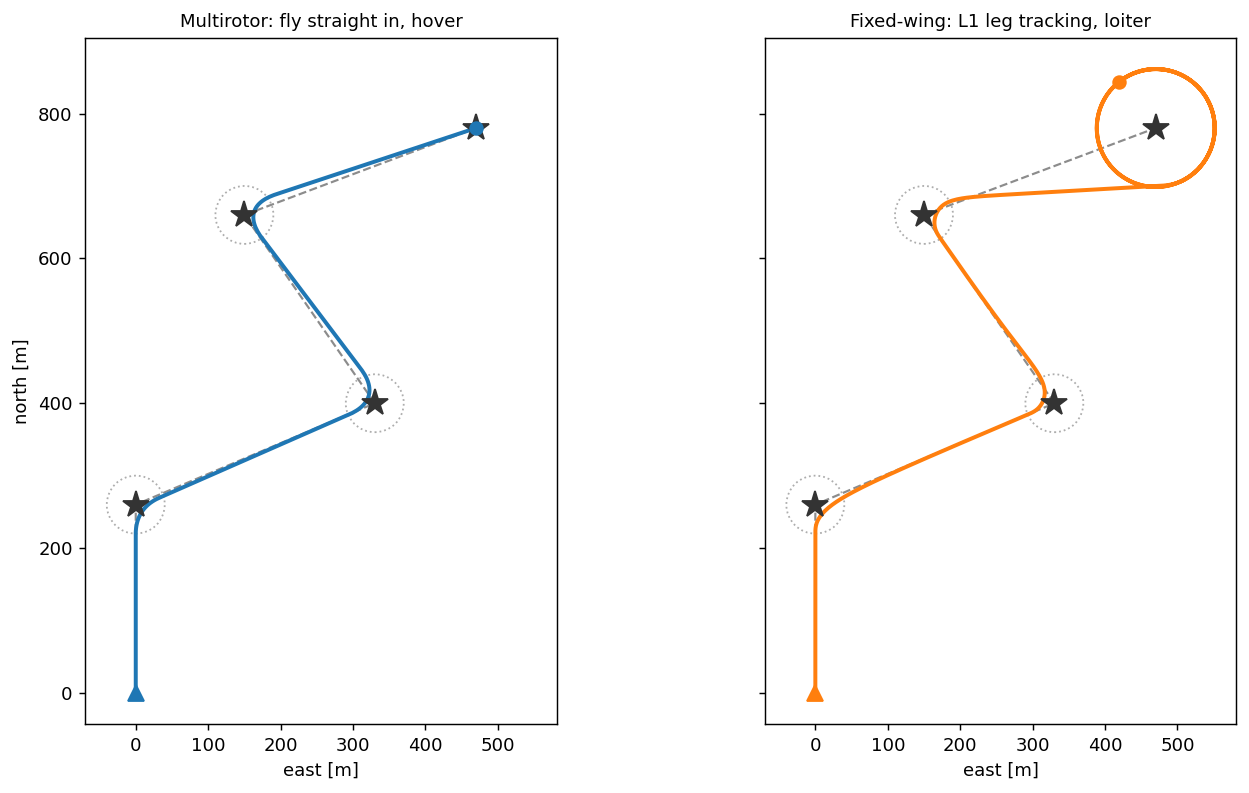

In [2]:
mr = AircraftState(id="MR", lat=LAT0, lon=LON0, trk=0.0, gs=10.0)
fw = AircraftState(id="FW", lat=LAT0, lon=LON0, trk=0.0, gs=CRUISE, yaw=0.0, bank=0.0)
mr_xy = fly_mission(mr_dyn, M600, mr, tmax=150.0)
fw_xy = fly_mission(fw_dyn, SMALL_FIXEDWING, fw, tmax=150.0)

fig, (a_mr, a_fw) = plt.subplots(1, 2, figsize=(11.5, 6.2), sharex=True, sharey=True)
for ax, (xs, ys), col, title, loiter in (
    (a_mr, mr_xy, BLUE,   "Multirotor: fly straight in, hover", False),
    (a_fw, fw_xy, ORANGE, "Fixed-wing: L1 leg tracking, loiter", True),
):
    draw_plan(ax, loiter)
    ax.plot(xs, ys, color=col, lw=2.2, zorder=3)
    ax.plot(xs[0], ys[0], "^", color=col, ms=9, zorder=4)
    ax.plot(xs[-1], ys[-1], "o", color=col, ms=7, zorder=4)
    ax.set_aspect("equal"); ax.set_xlabel("east [m]"); ax.set_title(title, fontsize=10)
a_mr.set_ylabel("north [m]")
fig.tight_layout(); plt.show()

## L1 leg tracking

The fixed-wing follows a leg $A \to B$ by steering at a **reference point** a fixed lookahead $L_1$ ahead of it on the line. With $u = (B-A)/\lVert B-A\rVert$, the foot of the perpendicular $F$, the cross-track distance $d$, and the reference $R$ are

$$ F = A + \big((P-A)\cdot u\big)\,u, \quad d = \lVert P - F\rVert, \quad R = F + \sqrt{\max(0,\ L_1^2 - d^2)}\,u, \quad \chi_\text{cmd} = \operatorname{atan2}(R_E, R_N). $$

The left panel draws that construction from the real formulas; the right releases two fixed-wings 110 m off either side of a leg and lets the real model capture it.

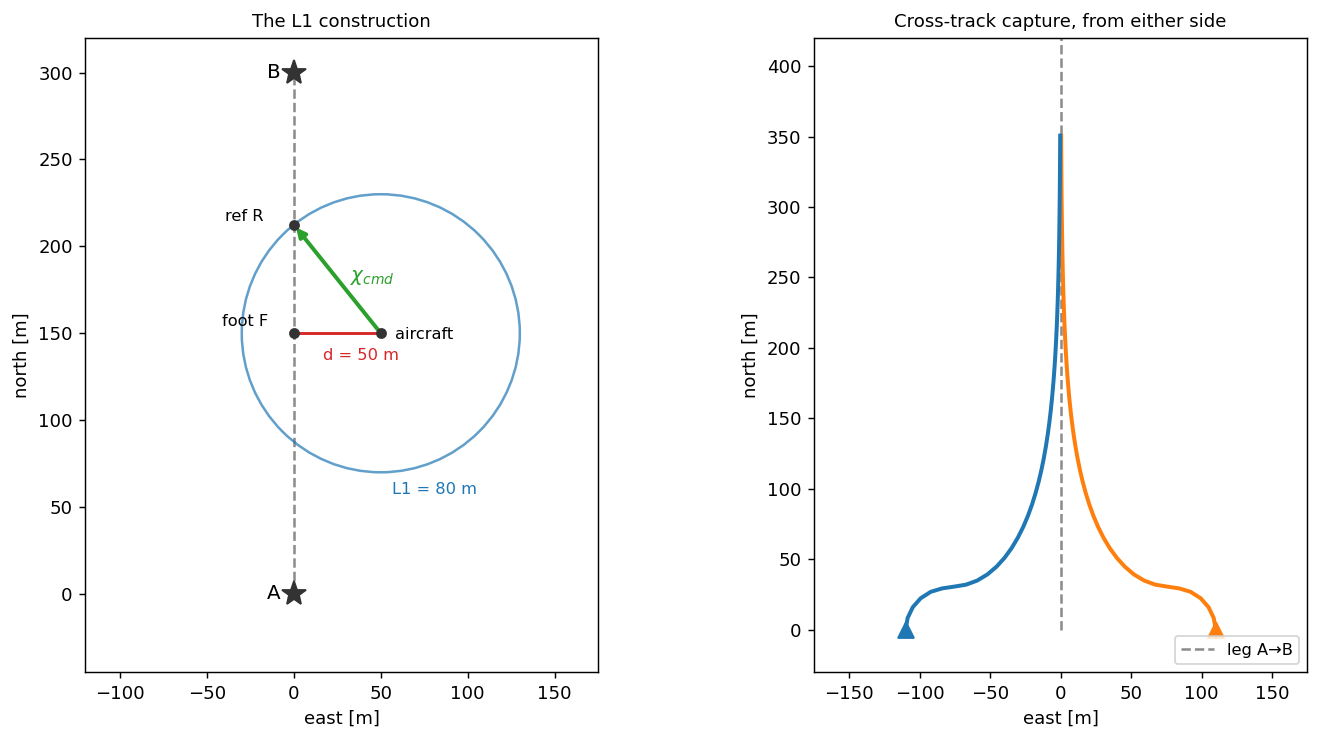

In [3]:
def l1_reference(px, py, ax_, ay, bx, by):
    # world-frame L1 construction: foot F, reference R on the leg, cross-track d
    ux, uy = bx - ax_, by - ay
    leglen = math.hypot(ux, uy)
    ux, uy = ux / leglen, uy / leglen
    proj = (px - ax_) * ux + (py - ay) * uy
    fx, fy = ax_ + proj * ux, ay + proj * uy
    d = math.hypot(px - fx, py - fy)
    ahead = math.sqrt(max(0.0, _L1_DISTANCE ** 2 - d ** 2))
    return (fx, fy), (fx + ahead * ux, fy + ahead * uy), d

def capture_track(e0, n0, a_ll, b_ll, tmax=60.0, dt=0.5):
    # a fixed-wing starting off a leg, tracking it with L1 (real FixedWing + leg setpoint)
    s = AircraftState(id="C", lat=latlon(e0, n0)[0], lon=latlon(e0, n0)[1], trk=0.0, gs=CRUISE, yaw=0.0, bank=0.0)
    cmd = MotionCommand(target_position=b_ll, target_leg_start=a_ll, target_airspeed=CRUISE)
    xs, ys, t = [], [], 0.0
    while t < tmax:
        e, n = enu(s.lat, s.lon)
        xs.append(e); ys.append(n)
        s = fw_dyn.step(s, cmd, SMALL_FIXEDWING, dt)
        t += dt
    return xs, ys

fig, (a_geo, a_cap) = plt.subplots(1, 2, figsize=(11.5, 5.8))

# left: the L1 construction for one aircraft 50 m off the leg
ax_, ay, bx, by = 0.0, 0.0, 0.0, 300.0
px, py = 50.0, 150.0
(fx, fy), (rx, ry), d = l1_reference(px, py, ax_, ay, bx, by)
a_geo.plot([ax_, bx], [ay, by], color=GREY, ls="--", lw=1.4, zorder=1)
a_geo.plot(ax_, ay, "*", color="0.2", ms=14, zorder=4)
a_geo.plot(bx, by, "*", color="0.2", ms=14, zorder=4)
a_geo.annotate("A", (ax_, ay), textcoords="offset points", xytext=(-15, -3), fontsize=11)
a_geo.annotate("B", (bx, by), textcoords="offset points", xytext=(-15, -3), fontsize=11)
a_geo.add_patch(plt.Circle((px, py), _L1_DISTANCE, fill=False, color=BLUE, lw=1.4, alpha=0.7))
a_geo.plot([px, fx], [py, fy], color=RED, lw=1.6, zorder=3)
a_geo.annotate(f"d = {d:.0f} m", ((px + fx) / 2, (py + fy) / 2), textcoords="offset points", xytext=(-8, -15), color=RED, fontsize=9)
a_geo.annotate(f"L1 = {_L1_DISTANCE:.0f} m", (px, py - _L1_DISTANCE), textcoords="offset points", xytext=(6, -12), color=BLUE, fontsize=9)
a_geo.annotate("", xy=(rx, ry), xytext=(px, py), arrowprops=dict(arrowstyle="-|>", color=GREEN, lw=2.2))
a_geo.annotate(r"$\chi_{cmd}$", ((px + rx) / 2, (py + ry) / 2), textcoords="offset points", xytext=(7, -1), color=GREEN, fontsize=11)
for xy, lbl, dx, dy in (((px, py), "aircraft", 8, -3), ((fx, fy), "foot F", -40, 4), ((rx, ry), "ref R", -38, 2)):
    a_geo.plot(*xy, "o", color="0.2", ms=5, zorder=4)
    a_geo.annotate(lbl, xy, textcoords="offset points", xytext=(dx, dy), fontsize=9)
a_geo.set_xlim(-120, 175); a_geo.set_ylim(-45, 320); a_geo.set_aspect("equal")
a_geo.set_xlabel("east [m]"); a_geo.set_ylabel("north [m]"); a_geo.set_title("The L1 construction", fontsize=10)

# right: cross-track capture of a due-north leg from either side
a_ll, b_ll = latlon(0.0, 0.0), latlon(0.0, 600.0)
a_cap.plot([0.0, 0.0], [0.0, 420.0], color=GREY, ls="--", lw=1.4, label="leg A→B", zorder=1)
for e0, col in ((110.0, ORANGE), (-110.0, BLUE)):
    xs, ys = capture_track(e0, 0.0, a_ll, b_ll, tmax=24.0)
    a_cap.plot(xs, ys, color=col, lw=2.2, zorder=3)
    a_cap.plot(xs[0], ys[0], "^", color=col, ms=9, zorder=4)
a_cap.set_aspect("equal"); a_cap.set_xlim(-175, 175); a_cap.set_ylim(-30, 420)
a_cap.set_xlabel("east [m]"); a_cap.set_ylabel("north [m]"); a_cap.set_title("Cross-track capture, from either side", fontsize=10)
a_cap.legend(fontsize=9, loc="lower right")
fig.tight_layout(); plt.show()